# Machine Learning Assignment 2
## ANN Implementation on IRB2400 Inverse Kinematics Dataset
**Dataset:** Kinematic Dataset for Six-Degree-of-Freedom Robot (ABB IRB2400) from Kaggle

**Task Type:** Regression — Predicting 6 joint output angles from end-effector position & orientation

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


## 2. Load Dataset

In [3]:
irb_df = pd.read_csv("datasetIRB2400_1000.csv")

print("Dataset Shape:", irb_df.shape)
print("\nFirst 5 Rows:")
print(irb_df.head())


Dataset Shape: (1000, 18)

First 5 Rows:
         x         y          z     yaw   pitch    roll   q1_in   q2_in  \
0 -80.9148 -121.7499  1896.4867 -0.6941  0.9229 -1.4411 -2.2407 -0.7975   
1 -80.9148 -121.7499  1896.4867 -0.6941  0.9229 -1.4411 -2.2233 -0.8511   
2 -80.9148 -121.7499  1896.4867 -0.6941  0.9229 -1.4411 -2.2567 -0.9468   
3 -80.9148 -121.7499  1896.4867 -0.6941  0.9229 -1.4411 -2.1557 -0.8205   
4 -80.9148 -121.7499  1896.4867 -0.6941  0.9229 -1.4411 -2.3267 -0.9279   

    q3_in   q4_in   q5_in   q6_in  q1_out  q2_out  q3_out  q4_out  q5_out  \
0  0.6551 -3.2989  1.1212  5.7052 -2.2347 -0.8949  0.6113 -3.2841  1.2117   
1  0.5966 -3.2320  1.1662  5.6429 -2.2347 -0.8949  0.6113 -3.2841  1.2117   
2  0.5820 -3.3165  1.1220  5.5944 -2.2347 -0.8949  0.6113 -3.2841  1.2117   
3  0.5532 -3.1993  1.2697  5.7474 -2.2347 -0.8949  0.6113 -3.2841  1.2117   
4  0.6722 -3.2867  1.2266  5.6304 -2.2347 -0.8949  0.6113 -3.2841  1.2117   

   q6_out  
0  5.6792  
1  5.6792  
2  5.6792

## 3. Data Preprocessing

### 3.1 Check for Missing Values

In [4]:
print("Missing Values per Column:")
print(irb_df.isnull().sum())
print("\nTotal Missing Values:", irb_df.isnull().sum().sum())
print("\nNo categorical variables present - all features are numerical.")


Missing Values per Column:
x         0
y         0
z         0
yaw       0
pitch     0
roll      0
q1_in     0
q2_in     0
q3_in     0
q4_in     0
q5_in     0
q6_in     0
q1_out    0
q2_out    0
q3_out    0
q4_out    0
q5_out    0
q6_out    0
dtype: int64

Total Missing Values: 0

No categorical variables present - all features are numerical.


### 3.2 Data Types & Statistical Summary

In [5]:
print("Data Types:")
print(irb_df.dtypes)

print("\nStatistical Summary:")
print(irb_df.describe())


Data Types:
x         float64
y         float64
z         float64
yaw       float64
pitch     float64
roll      float64
q1_in     float64
q2_in     float64
q3_in     float64
q4_in     float64
q5_in     float64
q6_in     float64
q1_out    float64
q2_out    float64
q3_out    float64
q4_out    float64
q5_out    float64
q6_out    float64
dtype: object

Statistical Summary:
                 x            y            z          yaw        pitch  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean    -44.046208  -113.242548   995.200768    -0.089818    -0.042404   
std     620.329926   402.756182   675.228527     1.979205     0.680039   
min   -1405.581100 -1174.200700  -725.921700    -2.972000    -1.457400   
25%    -249.315100  -318.194400   727.471800    -2.109900    -0.513700   
50%       1.447700   -93.078150  1081.884400     0.127800     0.031500   
75%     302.414200   128.516800  1417.674000     1.573500     0.413700   
max    1239.178600   981.272500  200

### 3.3 Define Features and Target Variables

In [6]:
# Input features: end-effector position, orientation and input joint angles
input_features = ["x", "y", "z", "yaw", "pitch", "roll",
                  "q1_in", "q2_in", "q3_in", "q4_in", "q5_in", "q6_in"]

# Output targets: 6 joint output angles
output_targets = ["q1_out", "q2_out", "q3_out", "q4_out", "q5_out", "q6_out"]

X_data = irb_df[input_features]
y_data = irb_df[output_targets]

print("Input shape:", X_data.shape)
print("Output shape:", y_data.shape)


Input shape: (1000, 12)
Output shape: (1000, 6)


### 3.4 Normalize / Standardize Features

In [7]:
input_scaler = StandardScaler()
output_scaler = StandardScaler()

X_scaled = input_scaler.fit_transform(X_data)
y_scaled = output_scaler.fit_transform(y_data)

print("Features normalized using StandardScaler.")
print("Mean of scaled X:", X_scaled.mean().round(4))
print("Std of scaled X:", X_scaled.std().round(4))


Features normalized using StandardScaler.
Mean of scaled X: -0.0
Std of scaled X: 1.0


### 3.5 Train-Test Split (80% Train / 20% Test)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])


Training samples: 800
Testing samples:  200


## 4. Exploratory Data Analysis (EDA)

### 4.1 Dataset Summary

In [9]:
print("Shape:", irb_df.shape)
print("Columns:", irb_df.columns.tolist())
print("\nData Types:")
print(irb_df.dtypes)


Shape: (1000, 18)
Columns: ['x', 'y', 'z', 'yaw', 'pitch', 'roll', 'q1_in', 'q2_in', 'q3_in', 'q4_in', 'q5_in', 'q6_in', 'q1_out', 'q2_out', 'q3_out', 'q4_out', 'q5_out', 'q6_out']

Data Types:
x         float64
y         float64
z         float64
yaw       float64
pitch     float64
roll      float64
q1_in     float64
q2_in     float64
q3_in     float64
q4_in     float64
q5_in     float64
q6_in     float64
q1_out    float64
q2_out    float64
q3_out    float64
q4_out    float64
q5_out    float64
q6_out    float64
dtype: object


### 4.2 Feature Distributions

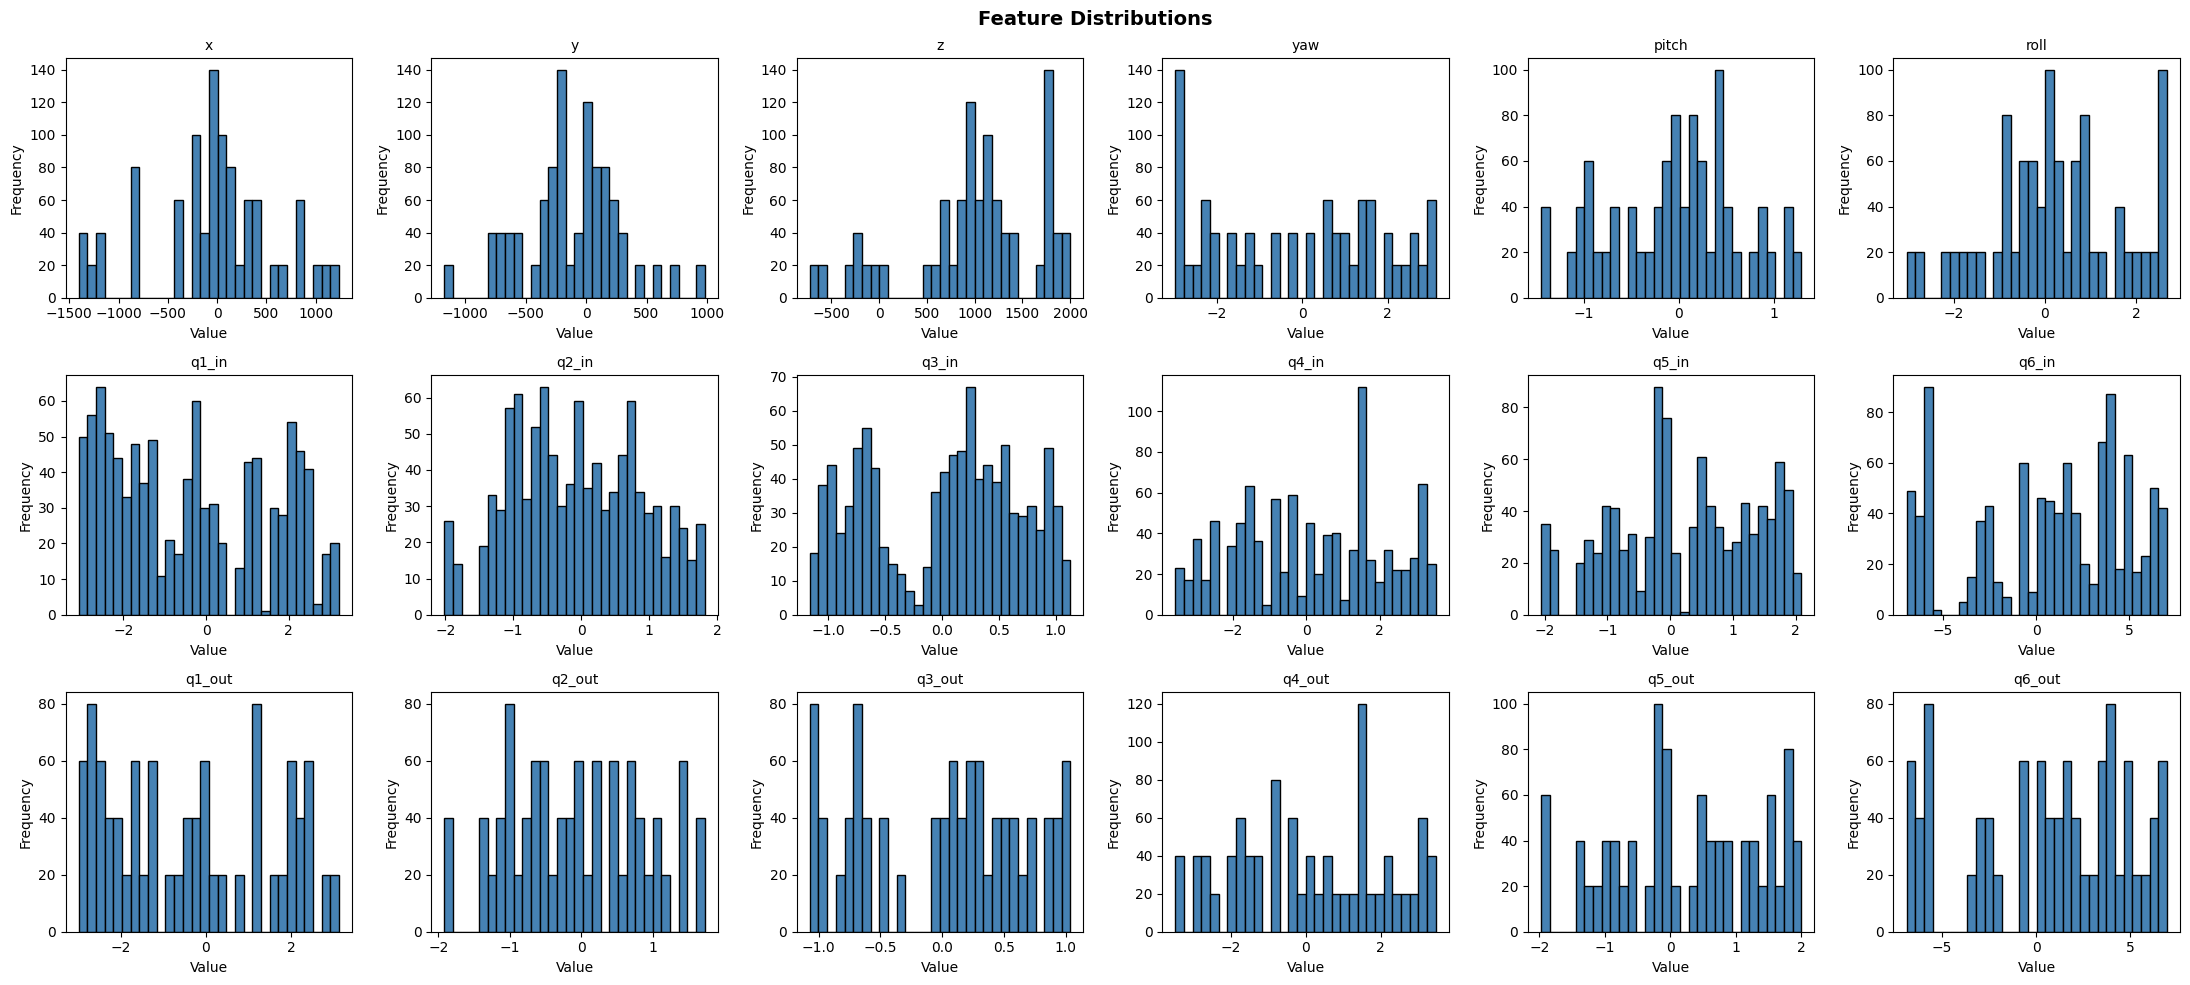

In [10]:
fig, axes = plt.subplots(3, 6, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(irb_df.columns):
    axes[i].hist(irb_df[col], bins=30, color="steelblue", edgecolor="black")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 4.3 Correlation Heatmap

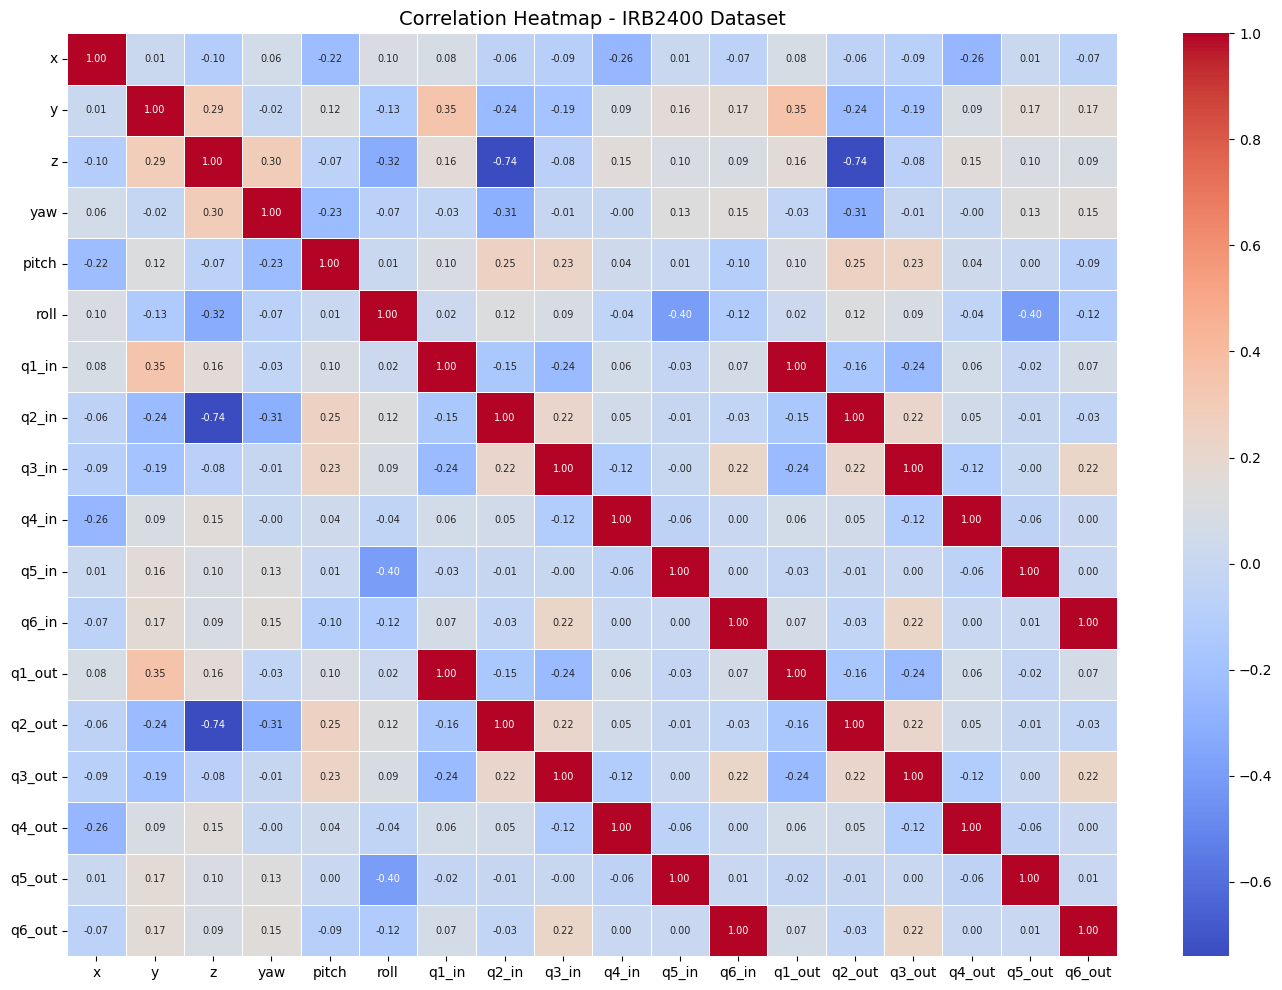

In [11]:
plt.figure(figsize=(14, 10))
correlation_matrix = irb_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, annot_kws={"size": 7})
plt.title("Correlation Heatmap - IRB2400 Dataset", fontsize=14)
plt.tight_layout()
plt.show()


### 4.4 Pairplot (Subset: Position vs Joint Outputs)

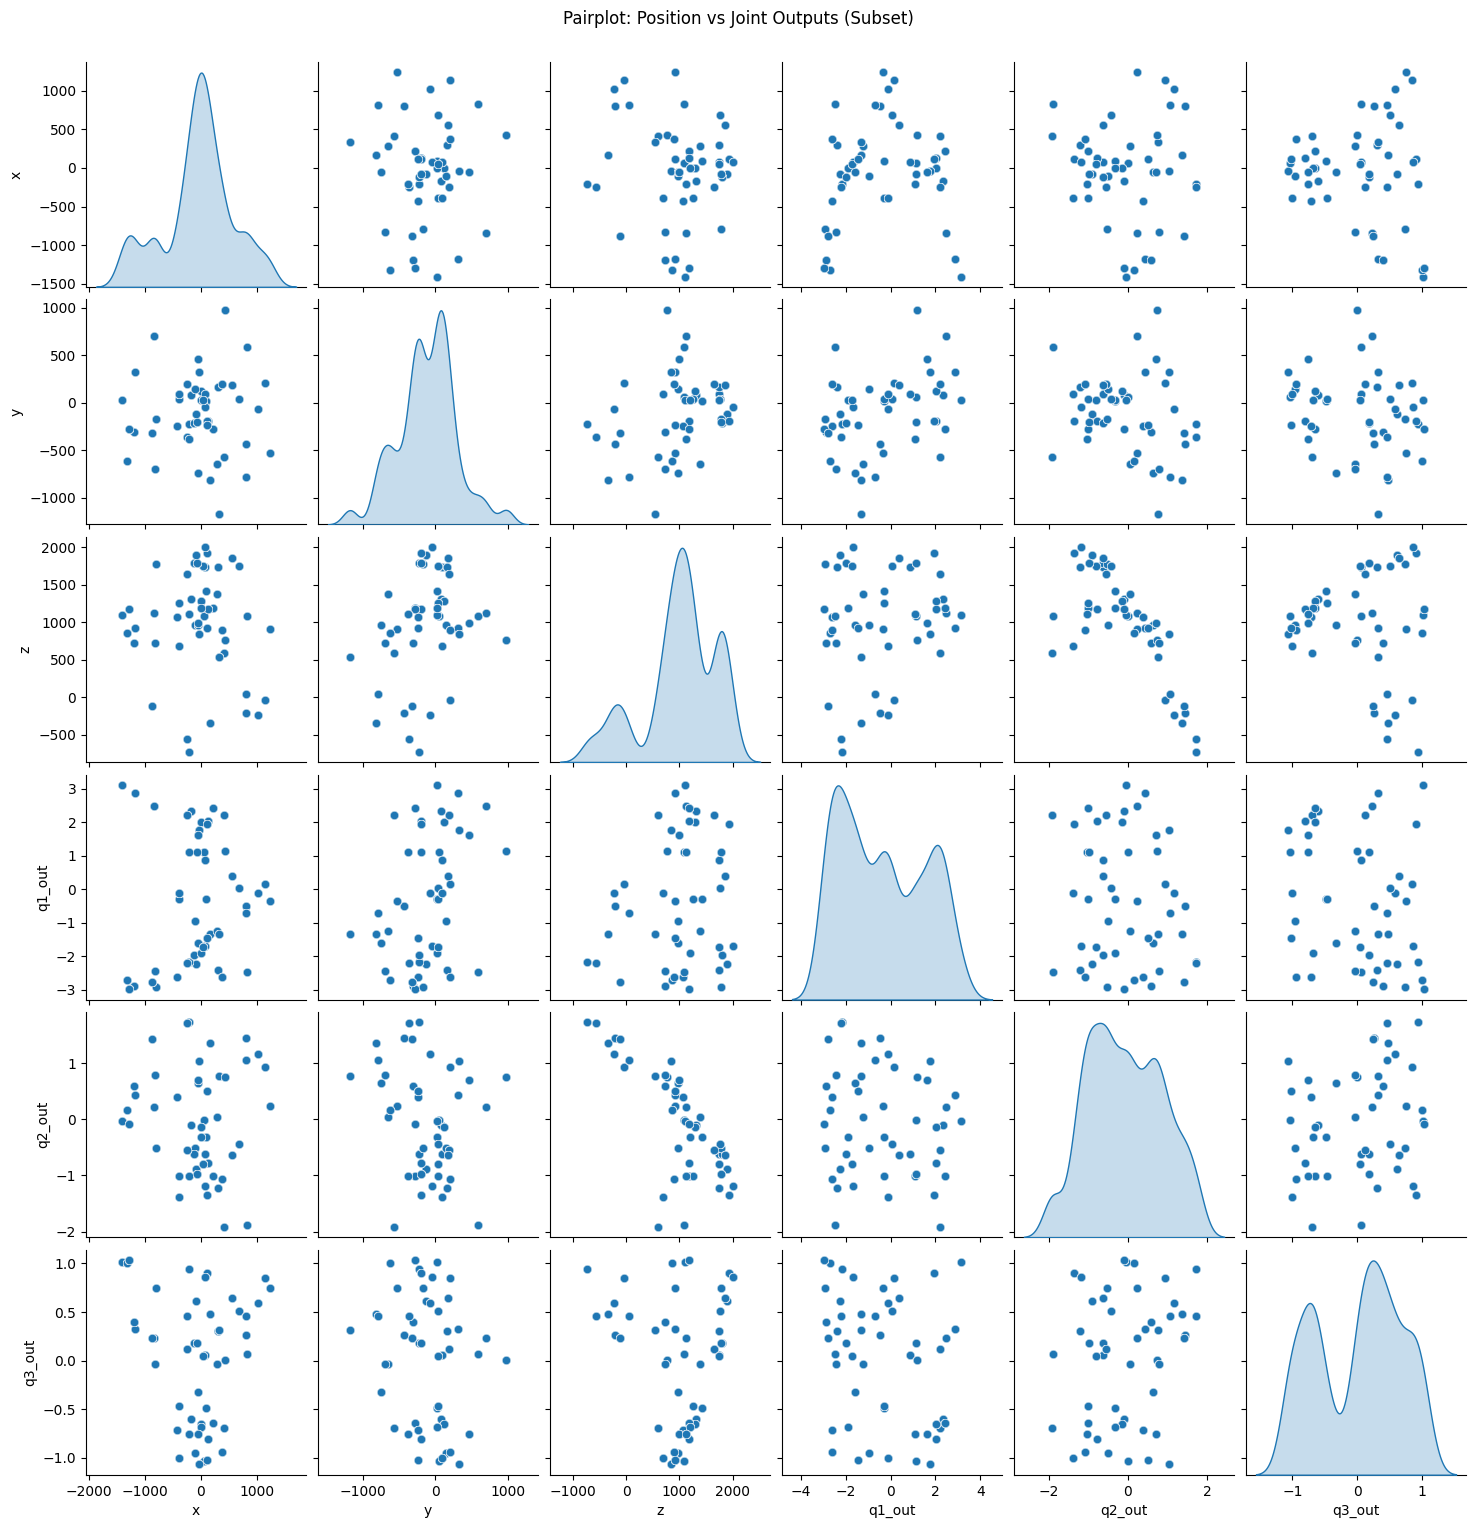

In [12]:
subset_cols = ["x", "y", "z", "q1_out", "q2_out", "q3_out"]
sns.pairplot(irb_df[subset_cols], diag_kind="kde", plot_kws={"alpha": 0.4})
plt.suptitle("Pairplot: Position vs Joint Outputs (Subset)", y=1.02)
plt.show()


## 5. ANN Model Development (Keras / TensorFlow)

### 5.1 Build the ANN Model

In [13]:
ann_model = keras.Sequential([
    # Input Layer
    layers.Input(shape=(12,)),

    # Hidden Layer 1: 128 neurons, ReLU activation
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),

    # Hidden Layer 2: 64 neurons, ReLU activation
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),

    # Output Layer: 6 joint angles (regression -> linear activation)
    layers.Dense(6, activation="linear")
])

ann_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,310 (40.27 KB)

 Trainable params: 10,310 (40.27 KB)

 Non-trainable params: 0 (0.00 B)

### 5.2 Compile the Model

In [14]:
ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mean_squared_error",
    metrics=["mae"]
)

print("Model compiled successfully.")
print("Optimizer : Adam (lr=0.001)")
print("Loss      : Mean Squared Error")
print("Metric    : Mean Absolute Error")


Model compiled successfully.
Optimizer : Adam (lr=0.001)
Loss      : Mean Squared Error
Metric    : Mean Absolute Error


## 6. Model Training

In [15]:
training_history = ann_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.8634 - mae: 0.7684 - val_loss: 0.4608 - val_mae: 0.5584
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4380 - mae: 0.5402 - val_loss: 0.2016 - val_mae: 0.3593
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2617 - mae: 0.4078 - val_loss: 0.0911 - val_mae: 0.2391
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1874 - mae: 0.3435 - val_loss: 0.0483 - val_mae: 0.1723
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1588 - mae: 0.3129 - val_loss: 0.0341 - val_mae: 0.1393
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1401 - mae: 0.2952 - val_loss: 0.0311 - val_mae: 0.1385
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1327 - mae: 0.2854 - val_loss: 0.0235 - val_mae: 0.1199
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1237 - mae: 0.2767 - val_loss: 0.0243 - val_mae: 0.1244
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.11

### 6.1 Training & Validation Loss / MAE Curves

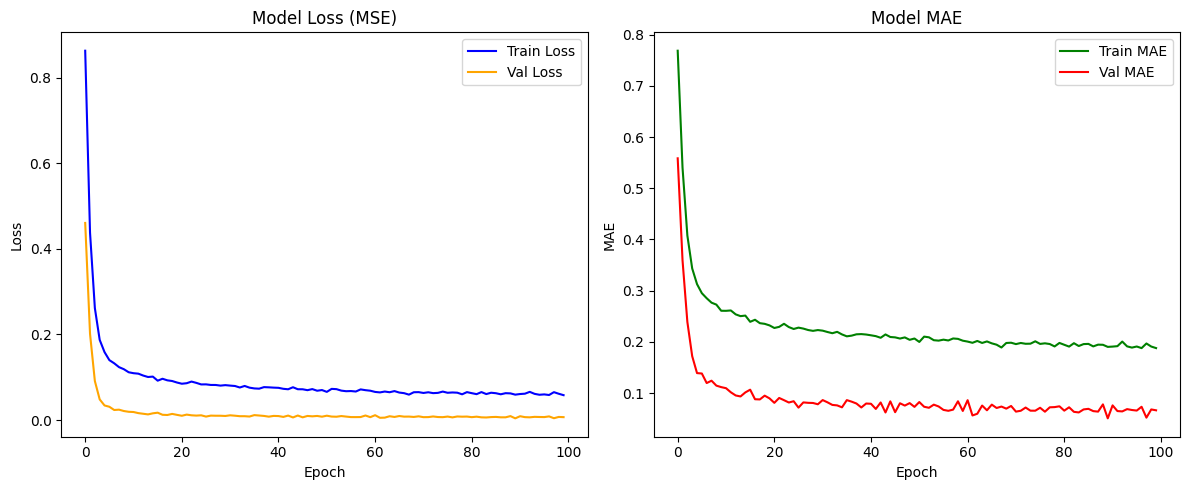

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(training_history.history["loss"], label="Train Loss", color="blue")
plt.plot(training_history.history["val_loss"], label="Val Loss", color="orange")
plt.title("Model Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(training_history.history["mae"], label="Train MAE", color="green")
plt.plot(training_history.history["val_mae"], label="Val MAE", color="red")
plt.title("Model MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()


## 7. Model Evaluation

In [17]:
y_pred_scaled = ann_model.predict(X_test)

# Inverse transform back to original scale
y_pred_actual = output_scaler.inverse_transform(y_pred_scaled)
y_test_actual = output_scaler.inverse_transform(y_test)

mse_score = mean_squared_error(y_test_actual, y_pred_actual)
mae_score = mean_absolute_error(y_test_actual, y_pred_actual)
r2_val    = r2_score(y_test_actual, y_pred_actual)

print("========== Overall Model Evaluation ==========")
print("Mean Squared Error  (MSE) :", round(mse_score, 4))
print("Mean Absolute Error (MAE) :", round(mae_score, 4))
print("R2 Score                  :", round(r2_val, 4))
print("==============================================")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
========== Overall Model Evaluation ==========
Mean Squared Error  (MSE) : 0.0364
Mean Absolute Error (MAE) : 0.1224
R2 Score                  : 0.9935


### 7.1 Per-Joint Evaluation

In [18]:
joint_names = ["q1_out", "q2_out", "q3_out", "q4_out", "q5_out", "q6_out"]

print("{:<10} {:>10} {:>10} {:>10}".format("Joint", "MSE", "MAE", "R2"))
print("-" * 45)
for i, joint in enumerate(joint_names):
    j_mse = mean_squared_error(y_test_actual[:, i], y_pred_actual[:, i])
    j_mae = mean_absolute_error(y_test_actual[:, i], y_pred_actual[:, i])
    j_r2  = r2_score(y_test_actual[:, i], y_pred_actual[:, i])
    print("{:<10} {:>10.4f} {:>10.4f} {:>10.4f}".format(joint, j_mse, j_mae, j_r2))


Joint             MSE        MAE         R2
---------------------------------------------
q1_out         0.0205     0.1142     0.9940
q2_out         0.0049     0.0583     0.9952
q3_out         0.0025     0.0402     0.9936
q4_out         0.0271     0.1318     0.9932
q5_out         0.0078     0.0723     0.9939
q6_out         0.1553     0.3176     0.9910


### 7.2 Actual vs Predicted Plot

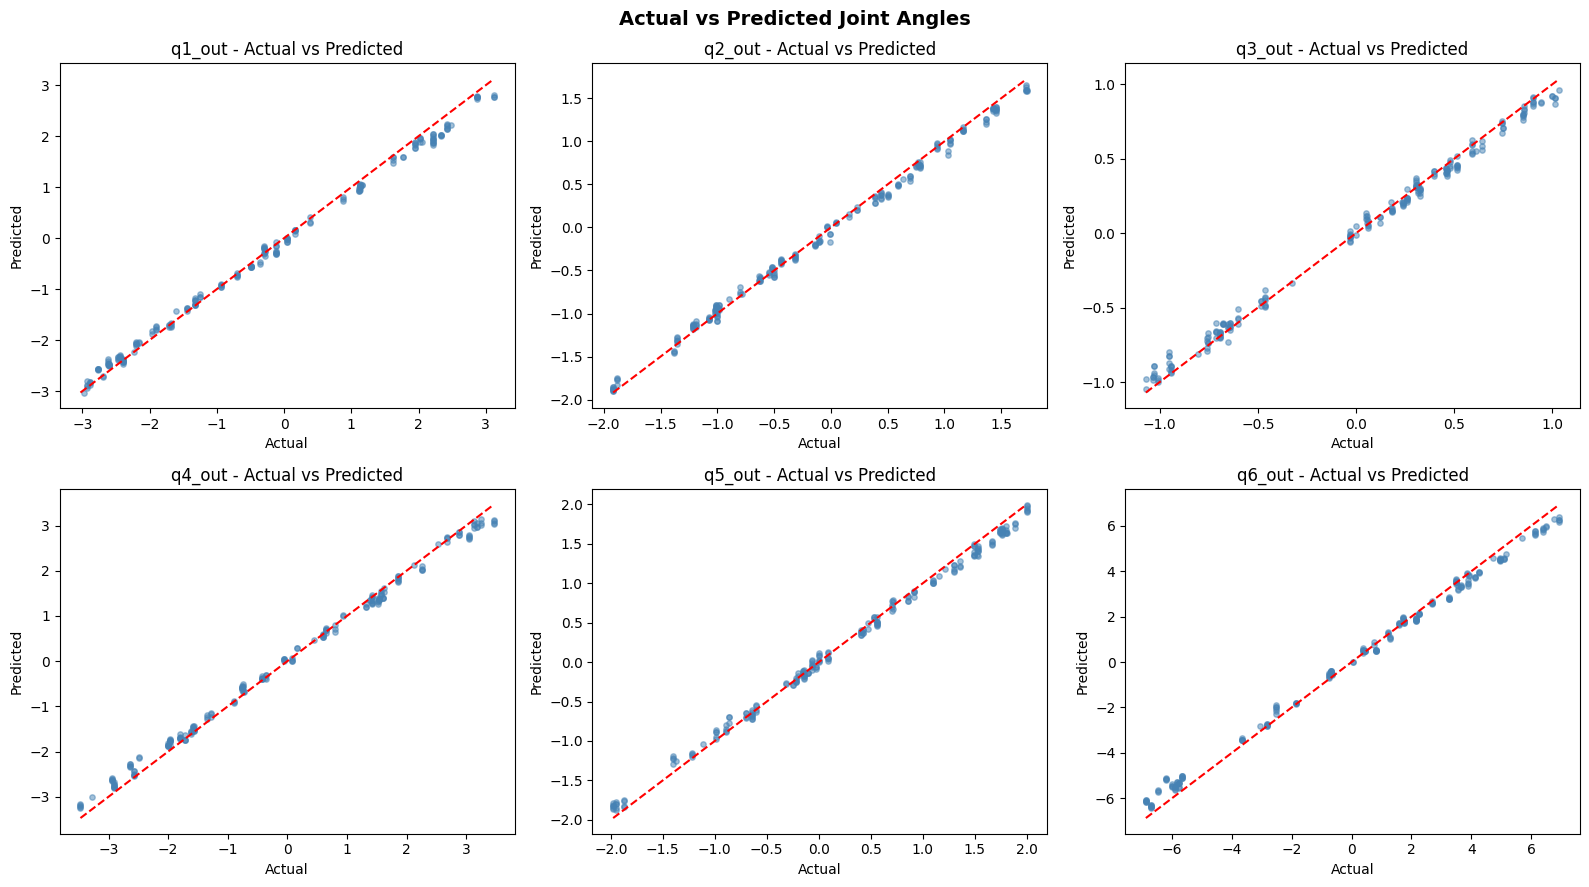

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, joint in enumerate(joint_names):
    axes[i].scatter(y_test_actual[:, i], y_pred_actual[:, i],
                    alpha=0.5, color="steelblue", s=15)
    min_val = min(y_test_actual[:, i].min(), y_pred_actual[:, i].min())
    max_val = max(y_test_actual[:, i].max(), y_pred_actual[:, i].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], "r--", lw=1.5)
    axes[i].set_title(joint + " - Actual vs Predicted")
    axes[i].set_xlabel("Actual")
    axes[i].set_ylabel("Predicted")

plt.suptitle("Actual vs Predicted Joint Angles", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 7.3 Residual Error Distribution

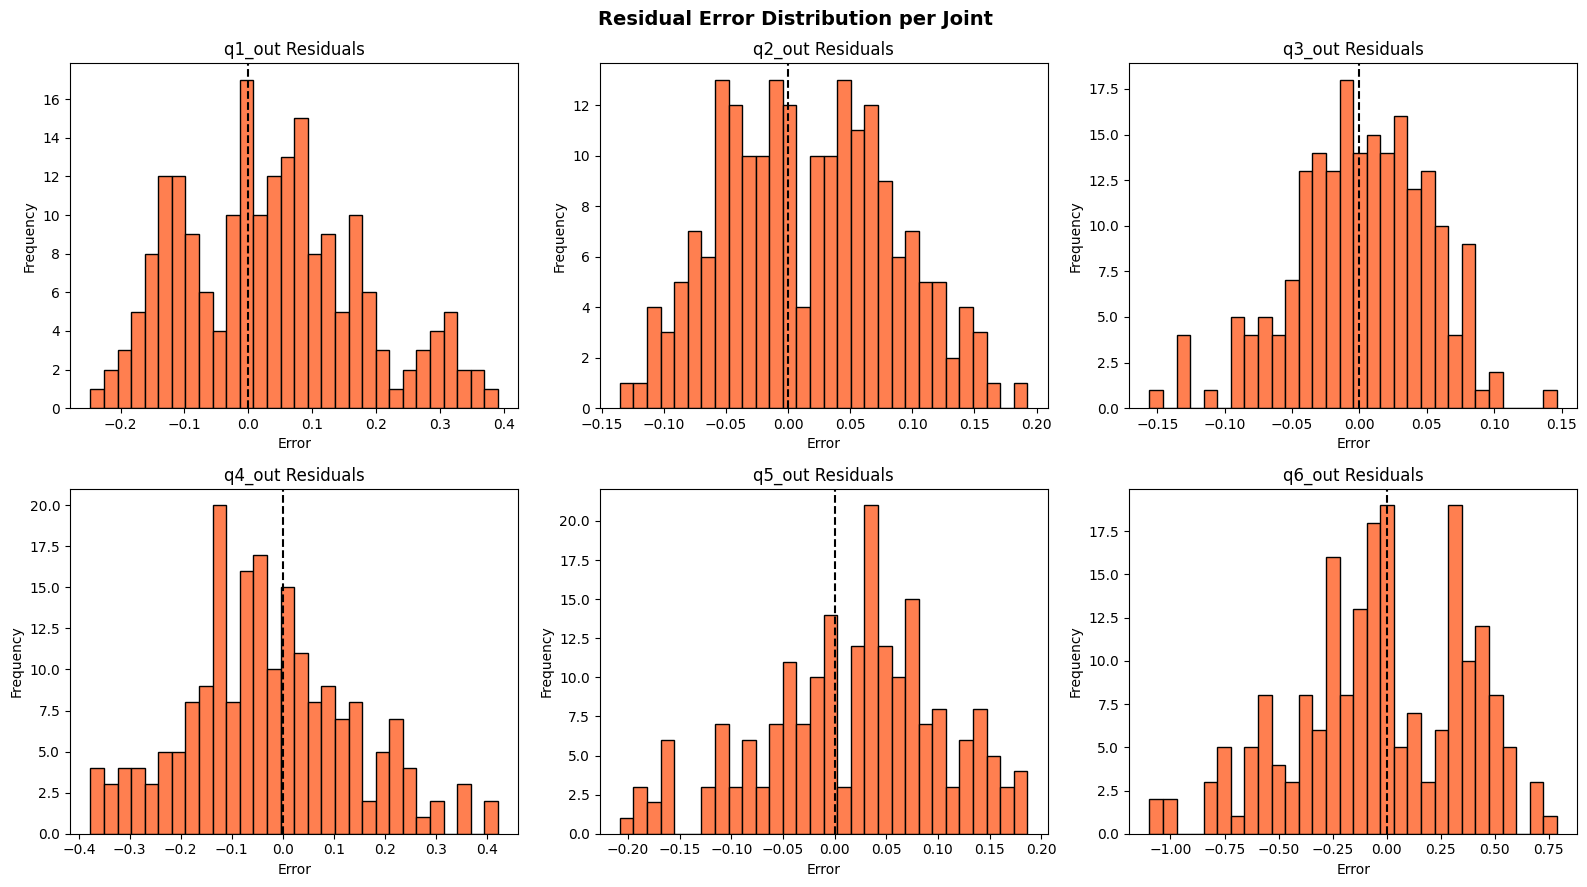

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, joint in enumerate(joint_names):
    residuals = y_test_actual[:, i] - y_pred_actual[:, i]
    axes[i].hist(residuals, bins=30, color="coral", edgecolor="black")
    axes[i].axvline(0, color="black", linestyle="--")
    axes[i].set_title(joint + " Residuals")
    axes[i].set_xlabel("Error")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Residual Error Distribution per Joint", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
